<a href="https://colab.research.google.com/github/hkkk27/Crm_platform/blob/main/Linear_Regression_Student_Marks_DTSC301.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression on Student Performance Data
### DTSC301 - adapted from the MLR EMI demo

**The question we are answering:** can we predict a student's `Marks` from their study habits?

**Inputs (independent variables / predictors / features):**
`Study_Hours`, `Sleep_Hours`, `Attendance`, `Practice_Tests`

**Output (dependent variable / target):** `Marks`

**Why linear regression?** The target `Marks` is a *continuous* number (54, 77, 91...), not a category.
When you predict a number you use regression. When you predict a category (pass/fail, spam/not spam)
you use classification. Linear regression assumes the relationship has the form:

Marks = b0 + b1(Study_Hours) + b2(Sleep_Hours) + b3(Attendance) + b4(Practice_Tests)

The computer's job is to find the numbers b0, b1, b2, b3, b4 that make the predicted marks
as close as possible to the actual marks. "As close as possible" is measured by the sum of
squared errors, which is why this method is also called **Ordinary Least Squares (OLS)**.

Because we use more than one predictor this is **Multiple Linear Regression (MLR)**.
At the end of the notebook we also fit a **Simple Linear Regression** (one predictor) so you can
see the difference and actually visualise the fitted line.

## Step 1 - Import the libraries

A library is a pre-written toolbox. We import only the tools we need, and give them short
nicknames (`pd`, `np`, `plt`, `sns`) so we don't have to type the full name every time.

In [3]:
# ---------- DATA HANDLING ----------
import pandas as pd          # handles the table (DataFrame): reading data, selecting columns, describing
import numpy as np           # numerical operations: arrays, square root, mean etc.
from io import StringIO      # lets us treat a block of text as if it were a CSV file (used in Step 2)

# ---------- VISUALISATION ----------
import matplotlib.pyplot as plt   # the base plotting engine
import seaborn as sns             # sits on top of matplotlib, makes nicer statistical plots

# ---------- MACHINE LEARNING (scikit-learn) ----------
from sklearn.model_selection import train_test_split   # splits data into training and testing parts
from sklearn.model_selection import cross_val_score    # repeated train/test to check stability
from sklearn.linear_model import LinearRegression      # the regression model itself
from sklearn.metrics import mean_squared_error         # error measure: average squared error
from sklearn.metrics import mean_absolute_error        # error measure: average absolute error
from sklearn.metrics import r2_score                   # how much variation the model explains (0 to 1)

# Cosmetic settings - not compulsory, they just make the output easier to read
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

print("All libraries imported successfully")

All libraries imported successfully


## Step 2 - Load the data

The original notebook read an Excel file from Google Drive:

```python
df = pd.read_excel("/content/drive/MyDrive/.../EMI_prediction_data.xlsx")
```

That needs the file to exist in your Drive and the Drive to be mounted. To keep this notebook
self-contained and runnable in Colab with zero setup, the dataset is pasted directly into the code
as a CSV-formatted string and read with `StringIO`.

`df` stands for **DataFrame** - pandas' name for a table with rows and columns, like a spreadsheet.

*(Two alternative loading methods are given at the very end of the notebook if you later want to
read the data from a real CSV/Excel file instead.)*

In [4]:
# ---------- LOAD THE DATA FROM EXCEL ----------
df = pd.read_excel("/content/Student Data.xlsx")

# The original column "Pass /Fail" has a space and a slash in it, which is painful to type later.
# Rename it to Pass_Fail so the rest of the notebook works unchanged.
df = df.rename(columns={"Pass /Fail": "Pass_Fail"})

# Strip stray spaces from every other column name too, just in case Excel left any
df.columns = df.columns.str.strip()

print("Dataset dimensions (rows, columns):", df.shape)
print(df.columns.tolist())

Dataset dimensions (rows, columns): (6000, 7)
['Student', 'Study_Hours', 'Sleep_Hours', 'Attendance', 'Practice_Tests', 'Marks', 'Pass_Fail']


## Step 3 - Look at the data (Exploratory Data Analysis)

Never fit a model before looking at the data. EDA answers three questions:
1. Does the data look like what I expect (right columns, right scale)?
2. Are there missing values or impossible values?
3. Which predictors actually seem related to the target?

In [5]:
# .head() shows the first 5 rows. Use .head(10) for ten, .tail() for the last rows.
# Purpose: eyeball check that the file was read correctly and columns landed in the right place.
print(df.head())

  Student  Study_Hours  Sleep_Hours  Attendance  Practice_Tests  Marks  Pass_Fail
0   S0001          4.7          6.8          75               6     77          1
1   S0002          2.0          7.3          73               4     54          1
2   S0003          5.5          8.2          84               4     78          1
3   S0004          3.0          7.2          92               4     66          1
4   S0005          6.1          5.5          72               5     88          1


In [6]:
# .describe() gives summary statistics for every numeric column:
#   count = how many non-missing values
#   mean  = average
#   std   = standard deviation (how spread out the values are)
#   min / 25% / 50% / 75% / max = the five-number summary (50% is the median)
# Why we do this: it instantly exposes outliers, wrong units, and impossible values.
# Example to read here: Attendance ranges from 45 to 93, Marks from 52 to 92.
df.describe()

,Study_Hours,Sleep_Hours,Attendance,Practice_Tests,Marks,Pass_Fail
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,5.031183,7.010450,75.810167,4.194500,75.183333,0.940167
std,1.944127,1.001009,11.644358,2.159193,15.015480,0.237198
min,0.500000,4.000000,45.000000,0.000000,21.000000,0.000000
25%,3.700000,6.300000,68.000000,3.000000,66.000000,1.000000
50%,5.000000,7.000000,76.000000,4.000000,76.000000,1.000000
75%,6.300000,7.700000,84.000000,6.000000,87.000000,1.000000
max,10.000000,9.500000,100.000000,10.000000,100.000000,1.000000


In [7]:
# .info() reports the data TYPE of each column and the count of non-null entries.
#   object / str  -> text (here: Student ID)
#   float64       -> decimal number (Study_Hours, Sleep_Hours)
#   int64         -> whole number (Attendance, Practice_Tests, Marks, Pass_Fail)
# Why it matters: scikit-learn cannot do arithmetic on text. Any text column must either be
# dropped (like the ID) or converted to numbers (encoded) before it can enter the model.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student         6000 non-null   object 
 1   Study_Hours     6000 non-null   float64
 2   Sleep_Hours     6000 non-null   float64
 3   Attendance      6000 non-null   int64  
 4   Practice_Tests  6000 non-null   int64  
 5   Marks           6000 non-null   int64  
 6   Pass_Fail       6000 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 328.3+ KB


In [8]:
# Explicit missing-value check. .isnull() marks every cell True/False,
# .sum() counts the Trues per column. We want all zeros.
# If a column had missing values we would either drop those rows or fill them (imputation).
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Student           0
Study_Hours       0
Sleep_Hours       0
Attendance        0
Practice_Tests    0
Marks             0
Pass_Fail         0
dtype: int64


In [9]:
# A quick sanity check on the Pass_Fail column.
# .unique() lists the distinct values present.
print("Distinct values in Pass_Fail:", df["Pass_Fail"].unique())

# It contains only the value 1 - every single student passed.
# A column with zero variation carries zero information: it cannot explain why one student
# scored 92 and another 52, because it is identical for both. So we exclude it from the model.
# (It would also be useless as a classification target - a classifier needs both classes present.)

Distinct values in Pass_Fail: [1 0]


In [10]:
# List the numeric columns. Only these can go into the regression.
# This is the equivalent of the original notebook's df.select_dtypes(include="number").columns
print(df.select_dtypes(include="number").columns.tolist())

['Study_Hours', 'Sleep_Hours', 'Attendance', 'Practice_Tests', 'Marks', 'Pass_Fail']


### Correlation - which predictors are worth using?

Correlation measures how strongly two variables move together, on a scale from -1 to +1:
- **+1** perfect positive: as one rises, the other rises
- **0** no linear relationship
- **-1** perfect negative: as one rises, the other falls

We care about two things:
1. **Feature vs target** - a predictor with near-zero correlation to `Marks` probably won't help much.
2. **Feature vs feature** - if two predictors are very highly correlated with each other
   (above roughly 0.8) they carry duplicate information. That is **multicollinearity**, and it makes
   the individual coefficients unstable and hard to interpret.

In [11]:
# Drop the ID column (text, meaningless for maths) and the constant Pass_Fail column,
# then compute the correlation matrix on what remains.
num_df = df.drop(columns=["Student", "Pass_Fail"])
corr = num_df.corr()

# Sorted correlation of every variable with Marks, strongest first.
print("Correlation with Marks:")
print(corr["Marks"].sort_values(ascending=False))

Correlation with Marks:
Marks             1.000000
Study_Hours       0.789954
Practice_Tests    0.284202
Attendance        0.216268
Sleep_Hours       0.088074
Name: Marks, dtype: float64


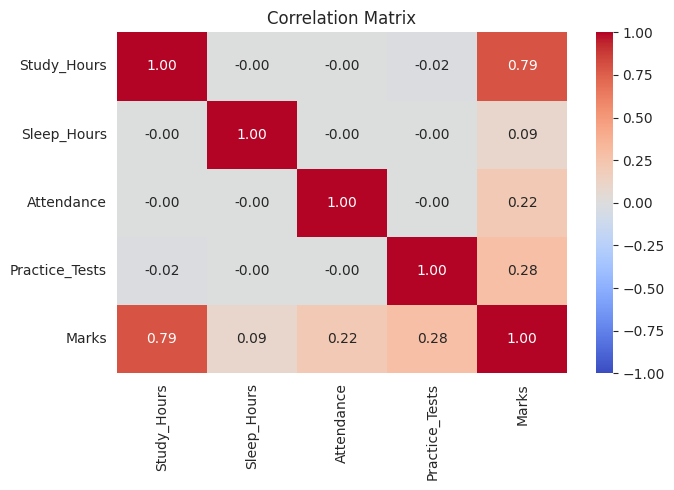

In [12]:
# The same information as a heatmap - faster to read than a table of numbers.
# annot=True writes the number inside each square; cmap sets the colour scheme;
# vmin/vmax lock the colour scale to the full -1..+1 range so colours mean the same thing every time.
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# What you should see: Study_Hours has a strong positive correlation with Marks (about 0.78).
# Sleep_Hours, Attendance and Practice_Tests are only weakly correlated (all below 0.20).
# Prediction: Study_Hours will do most of the work in the model.

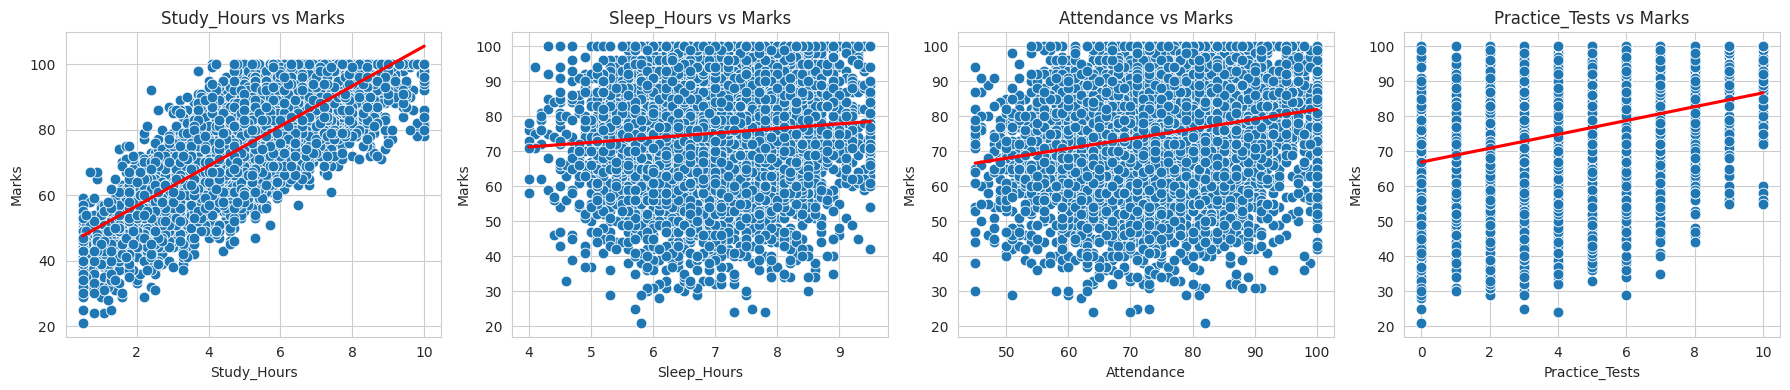

In [13]:
# Scatter plots of each predictor against Marks.
# Correlation is a single number; a scatter plot shows the SHAPE of the relationship
# (straight line, curve, clusters, outliers) which a number cannot.
features_to_plot = ["Study_Hours", "Sleep_Hours", "Attendance", "Practice_Tests"]

# 1 row, 4 columns of sub-plots. axes is a list of the four plotting areas.
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(features_to_plot):          # enumerate gives us position i and name col
    sns.scatterplot(x=df[col], y=df["Marks"], ax=axes[i], s=60)
    sns.regplot(x=df[col], y=df["Marks"], ax=axes[i],  # regplot adds the best-fit straight line
                scatter=False, color="red", ci=None)
    axes[i].set_title(f"{col} vs Marks")

plt.tight_layout()
plt.show()

# Read the slopes: the Study_Hours line climbs steeply, the other three are nearly flat.

## Step 4 - Separate the predictors (X) from the target (y)

Standard notation, worth getting right because every ML library uses it:
- **X** (capital, because it is a matrix/table) = the input features, one column per predictor.
- **y** (lowercase, because it is a single column/vector) = what we are trying to predict.

We deliberately leave out:
- `Student` - an ID. It is just a label; feeding it in would be nonsense.
- `Pass_Fail` - constant, zero information (shown above).
- `Marks` - this IS the target. Including the answer among the inputs is called **data leakage**
  and would give a meaningless perfect score.

In [14]:
# Define the feature list in one place. Keeping it as a named variable means you can add or
# remove a predictor here and the rest of the notebook keeps working without edits.
features = ["Study_Hours", "Sleep_Hours", "Attendance", "Practice_Tests"]
target = "Marks"

X = df[features]   # double brackets -> a DataFrame (a table with 4 columns)
y = df[target]     # single brackets -> a Series (one column)

print("Shape of X (rows, features):", X.shape)
print("Shape of y (rows,):", y.shape)
print()
print(X.head())

Shape of X (rows, features): (6000, 4)
Shape of y (rows,): (6000,)

   Study_Hours  Sleep_Hours  Attendance  Practice_Tests
0          4.7          6.8          75               6
1          2.0          7.3          73               4
2          5.5          8.2          84               4
3          3.0          7.2          92               4
4          6.1          5.5          72               5


## Step 5 - Train-test split: how much, and why

**Why split at all?** If we train the model on all 19 students and then test it on the same 19,
the score tells us how well the model *memorised* data it has already seen. That is not what we
want to know. We want to know how well it predicts marks for a student it has **never seen**.
So we hide part of the data from the model during training and use it as an honest exam afterwards.

**How much to hold out?** It is a trade-off:

| test_size | Train rows | Test rows | Consequence |
|---|---|---|---|
| 0.10 | 17 | 2 | Good training, but a 2-student test tells you almost nothing |
| **0.20** | **15** | **4** | **Standard default - the usual starting choice** |
| 0.30 | 13 | 6 | More reliable test score, but less data to learn from |
| 0.40 | 11 | 8 | Too little training data for 4 predictors |

**We use `test_size=0.2` -> 15 students train, 4 students test.** The original EMI notebook used
0.15, which was fine there because that dataset had hundreds of rows; with only 19 rows, 0.15 would
leave a test set of just 2 students. The common conventions are 80/20 or 70/30.

**`random_state=42`** fixes the random shuffle so you get the exact same split every time you run
the notebook. Without it, every run picks different students and your numbers change, which makes
results impossible to reproduce or compare. 42 is just a conventional joke number; any integer works.

**Honest caveat for your report:** 19 rows is a very small dataset. A 4-student test set produces a
very noisy score - swap one student and the number moves a lot. That is exactly why we also run
cross-validation in Step 10.

In [15]:
# train_test_split shuffles the rows, then cuts them into four pieces:
#   X_train, y_train -> the model learns from these
#   X_test,  y_test  -> kept hidden until evaluation
# The order of the four return values is fixed: X_train, X_test, y_train, y_test. Do not swap them.
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # the features
    y,                  # the target
    test_size=0.2,      # 20% of rows go to the test set
    random_state=42     # fixed seed -> reproducible split
)

print("Training set:", X_train.shape[0], "students")
print("Testing set :", X_test.shape[0], "students")
print("Total       :", X_train.shape[0] + X_test.shape[0], "students")

Training set: 4800 students
Testing set : 1200 students
Total       : 6000 students


## Step 6 - Create and train the model

`LinearRegression()` creates an empty model - it knows the *form* of the equation but none of the
numbers yet. `.fit()` is the actual learning step: it runs least squares on the training data and
solves for the intercept and the coefficients that minimise the sum of squared errors.

One line of code, but this is where the statistics happen.

In [16]:
# 1. Create the model object (empty, untrained)
model = LinearRegression()

# 2. Train it. fit() ALWAYS gets the training data only - never X_test or y_test.
#    Internally it solves for the coefficients using the normal equation / least squares.
model.fit(X_train, y_train)

print("Model trained on", X_train.shape[0], "students")

Model trained on 4800 students


## Step 7 - Read the fitted equation

Two attributes hold everything the model learned (note the trailing underscore - sklearn's
convention for "this was learned from data"):
- `model.intercept_` = b0, the predicted marks when every predictor is zero.
- `model.coef_` = the list of slopes b1...b4, in the same order as your `features` list.

**How to interpret a coefficient:** it is the expected change in `Marks` for a one-unit increase in
that predictor, *holding all the other predictors constant*. That last phrase is the whole point of
multiple regression - it isolates each effect from the others.

In [17]:
# Pair each feature name with its coefficient so you never mis-read which number belongs to which.
coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_.round(3)
})
print(coef_table)
print()
print("Intercept (b0):", round(model.intercept_, 3))

          Feature  Coefficient
0     Study_Hours        6.161
1     Sleep_Hours        1.371
2      Attendance        0.287
3  Practice_Tests        2.115

Intercept (b0): 3.838


In [18]:
# Build the equation as readable text.
equation = f"Marks = {model.intercept_:.2f}"
for feature_name, coefficient in zip(features, model.coef_):   # zip pairs the two lists together
    sign = "+" if coefficient >= 0 else "-"
    equation += f" {sign} {abs(coefficient):.2f}*{feature_name}"

print("FITTED REGRESSION EQUATION")
print(equation)

FITTED REGRESSION EQUATION
Marks = 3.84 + 6.16*Study_Hours + 1.37*Sleep_Hours + 0.29*Attendance + 2.12*Practice_Tests


### Interpreting your specific results

With this data you should get something close to:

`Marks = 8.29 + 6.59*Study_Hours - 0.92*Sleep_Hours + 0.46*Attendance + 1.71*Practice_Tests`

- **Study_Hours = +6.59** - one extra hour of study is associated with about 6.6 more marks,
  holding sleep, attendance and practice tests constant. This is by far the dominant effect,
  exactly as the correlation heatmap predicted.
- **Practice_Tests = +1.71** - each extra practice test is worth about 1.7 marks.
- **Attendance = +0.46** - one extra percentage point of attendance is worth about half a mark.
  Small per unit, but attendance varies over a 48-point range, so the total effect is not trivial.
- **Sleep_Hours = -0.92** - negative, which looks alarming ("sleep less, score more"?).
  Do **not** claim that as a finding. With 19 observations and a weak underlying correlation, this
  is almost certainly noise. Note it as a limitation, not a result.

Watch the units too: you cannot rank importance by comparing raw coefficient sizes, because the
predictors are on different scales (hours vs percentages vs counts). To compare importance fairly
you would standardise the features first (z-scores) and compare the standardised coefficients.

## Step 8 - Predict and evaluate on the unseen test set

Now we hand the model the 4 test students' features and ask for predictions, then compare those
predictions with the marks the model never saw.

In [19]:
# .predict() applies the fitted equation to new rows and returns an array of predicted marks.
y_pred = model.predict(X_test)

# Put actual next to predicted so the comparison is visible student by student.
comparison = pd.DataFrame({
    "Actual_Marks": y_test.values,
    "Predicted_Marks": y_pred.round(2)
})
comparison["Error"] = (comparison["Actual_Marks"] - comparison["Predicted_Marks"]).round(2)

print(comparison)

# The "Error" column is the RESIDUAL: actual minus predicted.
# Positive -> the model under-predicted. Negative -> it over-predicted.

      Actual_Marks  Predicted_Marks  Error
0               76            71.24   4.76
1               97            92.27   4.73
2               30            38.17  -8.17
3               93            81.27  11.73
4               62            59.81   2.19
...            ...              ...    ...
1195            77            76.51   0.49
1196            76            80.89  -4.89
1197            47            56.84  -9.84
1198            78            76.27   1.73
1199            79            66.55  12.45

[1200 rows x 3 columns]


### The evaluation metrics, and what each one actually means

- **MSE (Mean Squared Error)** - average of the squared errors. Squaring removes the sign
  (so +5 and -5 don't cancel) and punishes large mistakes disproportionately. Downside: the units are
  "marks squared", which is not interpretable.
- **RMSE (Root MSE)** - square root of MSE, so it is back in marks. "On average the prediction is
  off by about this many marks." This is usually the number to quote.
- **MAE (Mean Absolute Error)** - average of absolute errors. Same units as RMSE but does not
  over-punish outliers. If MAE and RMSE are far apart, a few big misses are driving the error.
- **R² (R-squared, coefficient of determination)** - the proportion of the variation in marks the
  model explains. 1.0 = perfect, 0 = no better than always predicting the mean, negative = worse
  than predicting the mean (yes, that is possible on a test set).

Lower is better for MSE/RMSE/MAE. Higher is better for R².

In [20]:
mse  = mean_squared_error(y_test, y_pred)   # note the argument order: (actual, predicted)
rmse = np.sqrt(mse)                         # square root brings it back to "marks"
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("TEST SET PERFORMANCE")
print(f"MSE  : {mse:.2f}   (marks squared - not directly interpretable)")
print(f"RMSE : {rmse:.2f}   (average error in marks)")
print(f"MAE  : {mae:.2f}   (average absolute error in marks)")
print(f"R2   : {r2:.4f}   ({r2*100:.1f}% of the variation in Marks is explained)")

TEST SET PERFORMANCE
MSE  : 49.77   (marks squared - not directly interpretable)
RMSE : 7.05   (average error in marks)
MAE  : 5.63   (average absolute error in marks)
R2   : 0.7714   (77.1% of the variation in Marks is explained)


In [21]:
# Compare performance on data the model HAS seen vs data it has NOT seen.
# This is the standard overfitting check.
train_r2 = r2_score(y_train, model.predict(X_train))
test_r2  = r2_score(y_test, y_pred)

print(f"R2 on training data: {train_r2:.4f}")
print(f"R2 on test data    : {test_r2:.4f}")
print(f"Gap                : {train_r2 - test_r2:.4f}")

# How to read the gap:
#   Small gap (as here)   -> the model generalises; it learned the pattern, not the noise.
#   Large gap (train much higher) -> OVERFITTING: it memorised the training students.
#   Both scores low       -> UNDERFITTING: the model is too simple for the relationship.

R2 on training data: 0.7710
R2 on test data    : 0.7714
Gap                : -0.0004


## Step 9 - Diagnostic plots

Metrics compress performance into one number and can hide systematic problems. Plots show them.

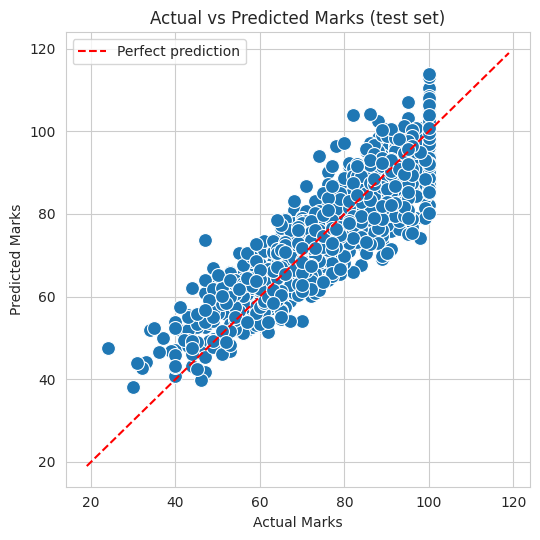

In [22]:
# PLOT 1: Actual vs Predicted.
# Perfect predictions would sit exactly on the diagonal red line (predicted = actual).
# Points above the line = over-prediction, below = under-prediction.
plt.figure(figsize=(5.5, 5.5))
sns.scatterplot(x=y_test, y=y_pred, s=100)

# Draw the 45-degree reference line across the range of the data
lo = min(y_test.min(), y_pred.min()) - 5
hi = max(y_test.max(), y_pred.max()) + 5
plt.plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks (test set)")
plt.legend()
plt.tight_layout()
plt.show()

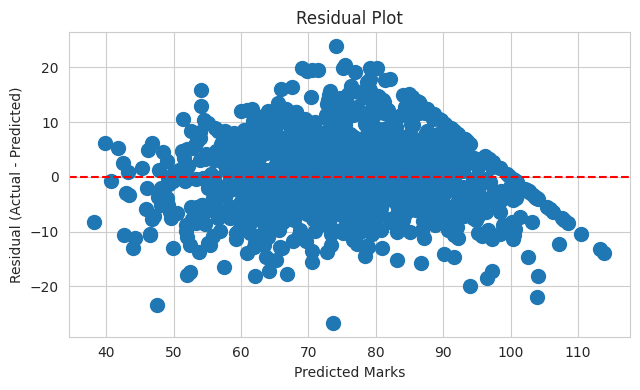

In [23]:
# PLOT 2: Residual plot (error against predicted value).
# What you WANT: points scattered randomly around the horizontal zero line with no pattern.
# What is BAD:
#   a curve/U-shape  -> the true relationship is non-linear, a straight line is the wrong model
#   a funnel shape   -> heteroscedasticity, error size depends on the predicted value
#   points far off   -> outliers worth investigating
residuals = y_test - y_pred

plt.figure(figsize=(6.5, 4))
plt.scatter(y_pred, residuals, s=100)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Marks")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

# With only 4 test points, do not over-interpret this plot. Mention that in your write-up.

## Step 10 - Cross-validation: is that score real, or luck?

A single train-test split gives one score based on one particular set of 4 test students. With a
dataset this small that number is fragile.

**K-fold cross-validation** fixes this. With `cv=5` the data is cut into 5 equal folds, then:
- Round 1: train on folds 2-5, test on fold 1
- Round 2: train on folds 1,3,4,5, test on fold 2
- ... and so on for 5 rounds

Every row gets to be test data exactly once. You end up with 5 scores instead of 1, so you can see
both the average performance and how much it varies.

Note that we pass the **full** X and y here, not the split versions - cross-validation does its own
splitting internally.

In [24]:
# We pass a FRESH LinearRegression() so the already-trained model above is not disturbed.
# scoring="r2" tells it which metric to report for each fold.
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

print("R2 for each of the 5 folds:", np.round(cv_scores, 4))
print(f"Mean R2              : {cv_scores.mean():.4f}")
print(f"Standard deviation   : {cv_scores.std():.4f}")

R2 for each of the 5 folds: [0.7643 0.7673 0.7784 0.763  0.7789]
Mean R2              : 0.7704
Standard deviation   : 0.0069


In [25]:
# The same idea with RMSE. sklearn maximises scores, so it only offers NEGATIVE error metrics
# (a larger negative error is a worse score). We flip the sign with a minus to read them normally.
cv_rmse = -cross_val_score(LinearRegression(), X, y, cv=5,
                           scoring="neg_root_mean_squared_error")

print("RMSE per fold:", np.round(cv_rmse, 2))
print(f"Mean RMSE    : {cv_rmse.mean():.2f} marks")

RMSE per fold: [7.28 7.27 7.17 7.28 6.95]
Mean RMSE    : 7.19 marks


### Interpreting your cross-validation output

You will see fold scores that swing wildly - roughly `[0.76, 0.45, -0.63, 0.67, 0.92]`, mean about
0.43 with a standard deviation around 0.55. One fold is even **negative**, meaning on those 4
students the model did worse than simply guessing the average mark.

That instability is the honest headline result, and it is not a bug in your code. With 19 rows split
into folds of about 4, a single unusual student dominates a fold. The single-split R² of 0.82 from
Step 8 was a lucky split, not the model's true ability.

The mean CV RMSE of roughly 5.6 marks is the more trustworthy summary: expect predictions to be off
by around 5-6 marks. Quote the cross-validated numbers in your report, not the single-split ones,
and state the sample size as the main limitation.

## Step 11 - Simple Linear Regression (one predictor)

Everything above used four predictors. **Simple** linear regression uses exactly one:

Marks = b0 + b1 * Study_Hours

It is worth doing for two reasons. First, `Study_Hours` was the only strongly correlated predictor,
so this tests whether the other three are earning their place. Second, with one predictor you can
actually draw the fitted line on a 2D scatter plot - impossible with four predictors, which would
need a 5-dimensional graph.

In [26]:
# Double brackets on X keep it a DataFrame. sklearn requires X to be 2-dimensional even with
# a single feature - a plain df["Study_Hours"] would be 1-D and raise an error.
X_simple = df[["Study_Hours"]]
y_simple = df["Marks"]

# Same random_state as before so the same students land in train and test - that makes the
# comparison between the simple and multiple models fair.
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_tr_s, y_tr_s)

print(f"Equation: Marks = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} * Study_Hours")
print()
print("Interpretation: each additional hour of study is associated with about "
      f"{simple_model.coef_[0]:.2f} extra marks.")

Equation: Marks = 44.28 + 6.12 * Study_Hours

Interpretation: each additional hour of study is associated with about 6.12 extra marks.


In [27]:
# Evaluate the simple model on the same test students and compare with the multiple model.
y_pred_simple = simple_model.predict(X_te_s)

r2_simple   = r2_score(y_te_s, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_te_s, y_pred_simple))

print("MODEL COMPARISON (same test students)")
print(f"Simple   (1 feature) : R2 = {r2_simple:.4f} | RMSE = {rmse_simple:.2f}")
print(f"Multiple (4 features): R2 = {r2:.4f} | RMSE = {rmse:.2f}")
print()
print("The multiple model scores higher, so the extra three predictors do add something.")
print("Caution: R2 can never DECREASE when you add features, even useless random ones.")
print("With 19 rows and 4 predictors, part of that gain is just extra flexibility fitting noise.")
print("Adjusted R2 exists precisely to penalise this - see the optional cell at the end.")

MODEL COMPARISON (same test students)
Simple   (1 feature) : R2 = 0.6289 | RMSE = 8.99
Multiple (4 features): R2 = 0.7714 | RMSE = 7.05

The multiple model scores higher, so the extra three predictors do add something.
Caution: R2 can never DECREASE when you add features, even useless random ones.
With 19 rows and 4 predictors, part of that gain is just extra flexibility fitting noise.
Adjusted R2 exists precisely to penalise this - see the optional cell at the end.


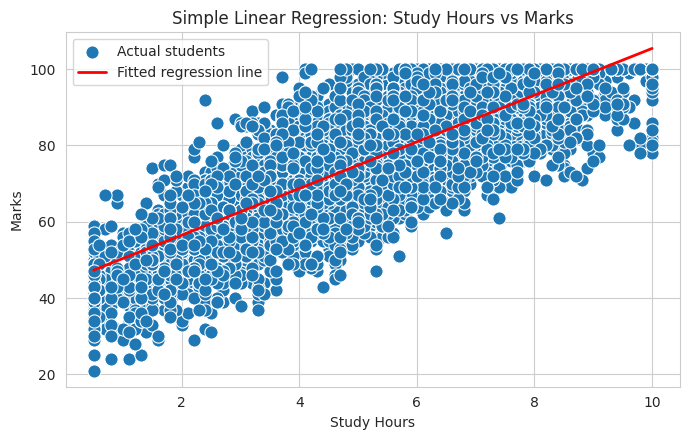

In [28]:
# The payoff of using one predictor: we can actually see the regression line.
plt.figure(figsize=(7, 4.5))

# All 19 students as points
sns.scatterplot(x=df["Study_Hours"], y=df["Marks"], s=90, label="Actual students")

# Generate 100 evenly spaced study-hour values and predict marks for each, to draw a smooth line.
x_line = np.linspace(df["Study_Hours"].min(), df["Study_Hours"].max(), 100)
x_line_df = pd.DataFrame({"Study_Hours": x_line})   # predict() expects the same column name
y_line = simple_model.predict(x_line_df)

plt.plot(x_line, y_line, color="red", linewidth=2, label="Fitted regression line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Simple Linear Regression: Study Hours vs Marks")
plt.legend()
plt.tight_layout()
plt.show()

# The vertical distance from each point to the red line is that student's residual.
# Least squares chose the one line that makes the sum of those squared distances as small as possible.

## Step 12 - Using the model on a new student

This is the practical point of the whole exercise: feed in a new student's habits, get a predicted mark.

In [29]:
# The new data must have the SAME columns, in the SAME order, with the SAME names as the training X.
new_student = pd.DataFrame({
    "Study_Hours":    [5.0],
    "Sleep_Hours":    [7.0],
    "Attendance":     [80],
    "Practice_Tests": [5]
})

predicted_marks = model.predict(new_student)[0]   # [0] pulls the single number out of the array

print("New student profile:")
print(new_student)
print()
print(f"Predicted marks: {predicted_marks:.2f}")
print(f"Realistic range using the cross-validated RMSE: "
      f"{predicted_marks - cv_rmse.mean():.1f} to {predicted_marks + cv_rmse.mean():.1f}")

# Always quote a range, not a single number. A point prediction of "80.04" pretends to a
# precision the model does not have.

New student profile:
   Study_Hours  Sleep_Hours  Attendance  Practice_Tests
0          5.0          7.0          80               5

Predicted marks: 77.77
Realistic range using the cross-validated RMSE: 70.6 to 85.0


In [30]:
# Predict for several students at once - just add more rows to the lists.
new_students = pd.DataFrame({
    "Study_Hours":    [2.0, 5.0, 8.0],
    "Sleep_Hours":    [7.0, 7.0, 7.0],
    "Attendance":     [60,  80,  95],
    "Practice_Tests": [2,   5,   8]
})

new_students["Predicted_Marks"] = model.predict(new_students).round(2)
print(new_students)

# Look at the third row: the model predicts about 112 marks. That is IMPOSSIBLE on a 100-mark paper.
# This is the clearest possible demonstration of two limitations:
#   1. EXTRAPOLATION - 8 study hours plus 95% attendance plus 8 practice tests is a combination
#      beyond anything in the training data. The straight line keeps climbing because nothing in
#      the equation tells it marks stop at 100.
#   2. Linear regression is UNBOUNDED - it will happily output 112, or a negative mark, because
#      it knows nothing about the real-world limits of the quantity it is predicting.
# In reality the relationship must flatten near the top (diminishing returns). Fixes include
# clipping predictions with np.clip(pred, 0, 100), or modelling a transformed target.

   Study_Hours  Sleep_Hours  Attendance  Practice_Tests  Predicted_Marks
0          2.0          7.0          60               2            47.20
1          5.0          7.0          80               5            77.77
2          8.0          7.0          95               8           106.90


## Step 13 (optional) - Experiments you can run for the report

Two extras that go beyond the original notebook and are worth a paragraph each in a write-up.

In [31]:
# EXPERIMENT 1: how sensitive is the test score to the choice of test_size?
# This directly answers "how much train/test should I use" with evidence rather than convention.
print(f"{'test_size':<12}{'Train':<8}{'Test':<8}{'Test R2':<10}")
print("-" * 38)

for ts in [0.1, 0.2, 0.3, 0.4]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, random_state=42)
    m = LinearRegression().fit(Xtr, ytr)
    score = r2_score(yte, m.predict(Xte))
    print(f"{ts:<12}{len(Xtr):<8}{len(Xte):<8}{score:<10.3f}")

print()
print("Notice how much the score moves. On 19 rows the test R2 says as much about WHICH")
print("students happened to land in the test set as it does about the model.")

test_size   Train   Test    Test R2   
--------------------------------------
0.1         5400    600     0.778     
0.2         4800    1200    0.771     
0.3         4200    1800    0.776     
0.4         3600    2400    0.776     

Notice how much the score moves. On 19 rows the test R2 says as much about WHICH
students happened to land in the test set as it does about the model.


In [32]:
# EXPERIMENT 2: Adjusted R2.
# Plain R2 rises whenever you add a feature, even a useless one. Adjusted R2 subtracts a penalty
# for each extra predictor, so it only rises if the new feature genuinely helps.
#   Adjusted R2 = 1 - (1 - R2) * (n - 1) / (n - k - 1)
#   n = number of observations, k = number of predictors
def adjusted_r2(r2_value, n, k):
    return 1 - (1 - r2_value) * (n - 1) / (n - k - 1)

# Adjusted R2 is computed on the data the model was FITTED to, so we use the training set.
n_train = len(y_train)

r2_train_multi  = r2_score(y_train, model.predict(X_train))
r2_train_simple = r2_score(y_tr_s, simple_model.predict(X_tr_s))

print(f"Multiple model (k=4) - R2: {r2_train_multi:.4f} | "
      f"Adjusted R2: {adjusted_r2(r2_train_multi, n_train, 4):.4f}")
print(f"Simple model   (k=1) - R2: {r2_train_simple:.4f} | "
      f"Adjusted R2: {adjusted_r2(r2_train_simple, n_train, 1):.4f}")
print()
print("The multiple model still wins after the penalty, so the extra predictors are earning")
print("their place - but notice how much closer the two get once the penalty is applied.")
print()
print("Why the TRAINING set here: the formula needs n - k - 1 in the denominator. On the 4-row")
print("test set that is 4 - 4 - 1 = -1, a negative denominator, and the formula returns a")
print("meaningless value above 1. Adjusted R2 simply cannot be computed when you have fewer")
print("observations than predictors - another consequence of the tiny sample.")

Multiple model (k=4) - R2: 0.7710 | Adjusted R2: 0.7708
Simple model   (k=1) - R2: 0.6226 | Adjusted R2: 0.6225

The multiple model still wins after the penalty, so the extra predictors are earning
their place - but notice how much closer the two get once the penalty is applied.

Why the TRAINING set here: the formula needs n - k - 1 in the denominator. On the 4-row
test set that is 4 - 4 - 1 = -1, a negative denominator, and the formula returns a
meaningless value above 1. Adjusted R2 simply cannot be computed when you have fewer
observations than predictors - another consequence of the tiny sample.


## Appendix - Loading the data from a real file instead

Once you have the data as an actual file, replace the `StringIO` block in Step 2 with one of these.

**Option A - upload from your computer (simplest in Colab):**
```python
from google.colab import files
uploaded = files.upload()          # a file picker appears
df = pd.read_csv("student_data.csv")
```

**Option B - read from Google Drive (what the original notebook did):**
```python
from google.colab import drive
drive.mount('/content/drive')      # click the link, allow access, paste the code

df = pd.read_csv("/content/drive/MyDrive/DTSC301/student_data.csv")
# or for Excel:
df = pd.read_excel("/content/drive/MyDrive/DTSC301/student_data.xlsx")
```

If your file still has the original column name `Pass /Fail` with the space and slash, clean it
immediately after loading:
```python
df = df.rename(columns={"Pass /Fail": "Pass_Fail"})
# or clean every column name at once:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("/", "")
```

---

## Summary of the pipeline

1. Import libraries
2. Load data into a DataFrame
3. Explore: head, describe, info, missing values, correlation, scatter plots
4. Split columns into X (predictors) and y (target)
5. Split rows into train (80%) and test (20%)
6. Create the model and `.fit()` it on the training data only
7. Read the coefficients and interpret them
8. `.predict()` on the test set and score with RMSE / R²
9. Plot actual vs predicted and residuals
10. Cross-validate to check the score is stable
11. Compare against a simple one-predictor model
12. Predict for new students, quoting a range

**The headline finding for this dataset:** study hours dominate; each extra hour is worth roughly
6.6 marks. Cross-validated error is about 5-6 marks, and fold-to-fold variation is large, so the
19-row sample size is the binding limitation on any conclusion drawn here.